# **Initialization**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import RK45, odeint, solve_ivp
import sympy as smp
import matplotlib


matplotlib.rcParams['figure.figsize'] = (12,8)
matplotlib.rcParams['font.size']      = 10

# **Code**

In [ ]:
def Dist(r):
  R = 10
  return 0.75*(R/r)**4 #0.5*(1-np.sqrt(1-(R/r)**2))**2

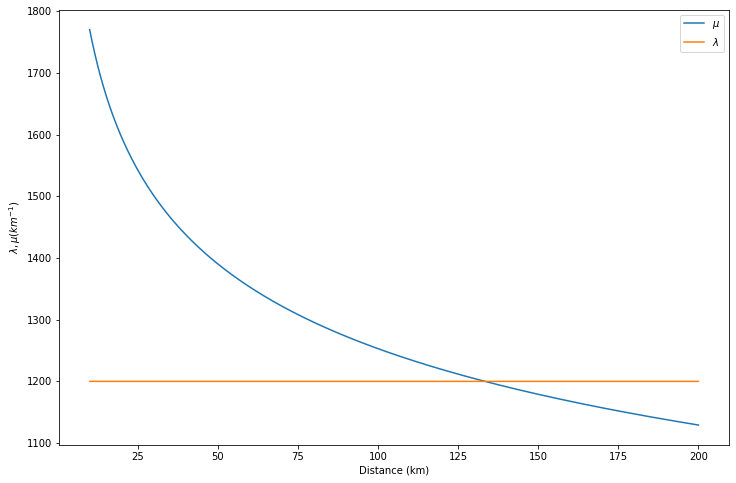

In [ ]:
r = np.linspace(10,200,10**5)
Mu = 2.5e3*(1/r**0.15)

@np.vectorize
def lambd(x):
  return 12e2

#plt.ylim(1e-1,1e5)
plt.plot(r,Mu,label=r'$\mu$')
plt.plot(r, lambd(r), label = r'$\lambda$')
plt.xlabel('Distance (km)')
plt.ylabel(r'$\lambda ,\mu  (km^{-1})$')
plt.legend()
#plt.savefig('Potentials.jpeg')

In [ ]:
def phi(E,beta):                  #Energy distribution function
    zeta =1.202
    return(2/3)*(beta/zeta)*(beta*E)**2/(np.exp(beta*E) + 1)

def A(E):                        #E distribution of neutrinos =x
    return phi(E,0.315)/10 + phi(E,0.131)/24

def B(self,E):                        #E distribution of anti-neutrinos =y
    return phi(E,0.210)/15 + phi(E,0.131)/24

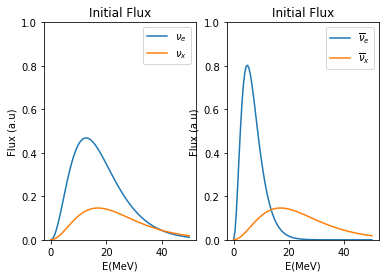

In [ ]:
E = np.linspace(0,50,100)

figure, axis = plt.subplots(1, 2)

axis[0].plot(E,phi(E,0.175)/0.10, label = r'$\nu_e$')
axis[0].plot(E,phi(E,0.131)/0.24, label = r'$\nu_x$')
#axis[0].scatter(E,phi(E,0.315)/0.10, label = r'$\nu_e$')
#axis[0].scatter(E,phi(E,0.131)/0.24, label = r'$\nu_x$')
axis[0].set_ylim(0,1)

axis[1].plot(E,phi(E,0.45)/0.15, label = r'$\overline{\nu}_e$')
axis[1].plot(E,phi(E,0.131)/0.24, label = r'$\overline{\nu}_x$')
#axis[1].scatter(E,phi(E,0.210)/0.15, label = r'$\overline{\nu}_e$')
#axis[1].scatter(E,phi(E,0.131)/0.24, label = r'$\overline{\nu}_x$')
axis[1].set_ylim(0,1)

axis[0].title.set_text('Initial Flux')
axis[1].title.set_text('Initial Flux')
plt.setp(axis[0], xlabel='E(MeV)')
plt.setp(axis[0], ylabel='Flux (a.u)')
plt.setp(axis[1], xlabel='E(MeV)')
plt.setp(axis[1], ylabel='Flux (a.u)')
axis[0].legend()
axis[1].legend()

plt.savefig('Fluxes.jpeg')


In [ ]:
class SN_wrap_v2():

  def __init__(self,n1):

    self.n1    = n1           #E bins
    if n1>1:
      self.E     = np.linspace(0,50,n1+1)[:-1]
      self.E    += (self.E[1]-self.E[0])*0.5
    else :
      self.E =  np.array([8],dtype=float)

    alpha = 1
    beta = 1.5

    self.I = []
    for E_o in self.E:
      self.I.append(np.array([[alpha]*3 + [beta]*3]))   #Creates an tensor with 3 copies of x's and y's to be multiplied by the P's and Pbar's

    self.I = np.array(self.I).reshape(self.n1,6)

    self.t     = None
    self.out   = None
    self.potential = []

    P0 = []
    for E_bin in self.E:
      P0 += self.P_init(E_bin)     #Makes copies of initial value for the T bins and E bins = P0
    P0 = np.array(P0)
    self.P0 = P0

  def init_E_P_theta(self):
    return self.P0.reshape(self.n1,6), self.E

  def __call__(self,t,P):

   return self.SN_self_v3(t,P,self.E,self.I)

  def Dist(self,t):
        R = 10
        return 0.75*(R/t)**4 #0.5*(1-np.sqrt(1-(R/t)**2))**2

  def P_init(self,E):                    # Generates initial values of P and Pbar
    P1 =  [0,0,1]#(self.phi(E,0.175)/10 - self.phi(E,0.131)/24)/(self.phi(E,0.175)/10 + self.phi(E,0.131)/24 )]   #[0,0,(self.phi(E,0.315)/10 - self.phi(E,0.131)/24)/(self.phi(E,0.315)/10 + self.phi(E,0.131)/24 )]
    P2 =  [0,0,1]#(self.phi(E,0.45)/15 - self.phi(E,0.131)/24)/(self.phi(E,0.45)/15 + self.phi(E,0.131)/24 )]

    return P1 + P2                      #Returns a vector with dim 6

  def omega(self,E):                              # Vacuum potential calc func
    dm2 = 2 * 10**-9                              # In terms of eV
    conv = 0.506 * 10**10                         # conversion factor eV -> 1/km
    w = (dm2 * conv)/(2*E)
    return w

  #def phi(self,E,beta):                  #Energy distribution function
  #  zeta =1.202
  #  return(2/3)*(beta/zeta)*(beta*E)**2/(np.exp(beta*E) + 1)

  #def A(self, E):                        #E distribution of neutrinos =x
  #  return self.phi(E,0.175)/10 + self.phi(E,0.131)/24
 #
  #def B(self,E):                        #E distribution of anti-neutrinos =y
  #  return self.phi(E,0.45)/15 + self.phi(E,0.131)/24

  def SN_self_v3(self,t,P,E,I):    # Multiangle system definition

    dE      = 2*E[0]

    theta_v = 0.16                        # theta vacuum

    lambd   = 0.253*pow(10,3)  #2.5e7*(1/t**3)           #1.1474e6*pow(t,-2.263)         # Matter potential

    mu_p    = pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t) #2.5e5*Dist(t) #5.3e5*self.Dist(t) #2.123e6*self.Dist(t)

    P       = P.reshape(self.n1,6)

    int_E   = (I*P).sum(axis=0)           #Does element wise multiplication of xP and yP_b and stores it in the object

    int_E   = int_E[0:3] - int_E[3:6]   #Separates xP and yP_b and subtracts it

    E_bin   = E

    #int_D = 3.552*(int_E)

    w = self.omega(E_bin)

    P1, P2 = P[:,0:3], P[:,3:6]

    H1 = (np.array(  [  w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w, lambd  + w*np.cos(2*theta_v)]).T.reshape(self.n1,3) + mu_p*int_E)

    H2 = (np.array(  [ -w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w , lambd - w*np.cos(2*theta_v)]).T.reshape(self.n1,3) + mu_p*int_E)


    dP1dt = np.cross(H1, P1)
    dP2dt = np.cross(H2, P2)

    dPdt = np.concatenate((dP1dt,dP2dt),axis=1)

    return dPdt

  def solver(self,t0=40,tf=200):

    t_span=(t0,tf)
    self.potential = []
    sol = RK45(self,t0,self.P0,tf,vectorized=True,rtol = 1e-6, atol = 1e-6)

    t_values  = []
    y_values  = []

    while(True):
      # Get solution step state
      sol.step()
      t_values.append(sol.t)
      y_values.append(sol.y)


      # Break loop after modeling is finished
      if sol.status == 'finished':
        break

    t   = np.array(t_values)
    out = np.array(y_values)

    self.t = t
    self.out = out.reshape(-1,self.n1,6)

    return self.t, self.out, self.potential

  def show_plot(self,bins=None):
    if bins==None:
      E_bins = np.arange(0,self.n1,1)
    else :
      E_bins = bins
    fig,ax = plt.subplots(1,2,figsize=(30,8))

    for i in E_bins:
      ax[0].plot(t,self.out.reshape(-1,self.n1,6)[:,i,2],label = r'$P_z$({})'.format(E[i]))
      ax[0].legend()
      ax[0].set_xlabel('r(km)')
      ax[0].set_title(r'$P_z$', fontsize=15)

    for i in E_bins:
      ax[1].plot(t,self.out.reshape(-1,self.n1,6)[:,i,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))
      ax[1].legend()
      ax[1].set_xlabel('r(km)')
      ax[1].set_title(r'$\overline{P_z}$', fontsize=15)

  def J_J_bar(self):
     if self.out is not None:
      dE = 2*self.E[0]
      I = self.I
      int_D = (I*self.out).sum(axis=1)

      J     = int_D[:,0:3]*dE/2
      J_bar = int_D[:,3:6]*dE/2

      return J,J_bar

In [ ]:
SN_obj = SN_wrap_v2(n1=5)  #(n1=70)

P0, E = SN_obj.init_E_P_theta()

In [ ]:
t, out, potential = SN_obj.solver()

In [ ]:
SN_obj.show_plot() #bins=[2,6,9,11,15] 70bins=[7,17,26,32,43] 50bins=[5,12,19,23,31]
#plt.savefig('SingleAngle70Ebin.jpeg')

In [ ]:
out.shape

In [ ]:
Pf = out[:,:,2]    #Final neutrino value
Pfb = out[:,:,5]   #Final anti-neutrino value

In [ ]:
Pf.shape

In [ ]:
Pi  = P0[:,2]    #Initial neutrino
Pib = P0[:,5]    #Initial anti-neutrino

In [ ]:
  #Initial anti-neutrino
P_ee = 0.5*(1+ Pf/Pi)
P_eeb = 0.5*(1+ Pfb/Pib)
P_ee.shape

In [ ]:
plt.plot(t,P_ee[:,2], label = r'$P_{\nu}$')
plt.plot(t, P_eeb[:,2],label = r'$\overline{P_{\nu}}$')
plt.title('Survival Probabilities')
plt.xlabel('Distance (km)')
plt.legend()
#plt.ylim(0,1)
#plt.savefig('P_surv.jpeg')

In [ ]:
plt.plot(t,J[:,2])
plt.plot(t,J_bar[:,2])
plt.plot(t,diff)
plt.xlabel('Distance(km)')
plt.ylim([-0.02,0.04])
plt.title('ELN conservation - SingleAngle')
plt.legend([r'$J_z$',r'$\overline{J_z}$',r'$J_z - \overline{J_z}$'])
#plt.savefig('SingleAngleDz.jpeg')

In [ ]:
J, J_bar = SN_obj.J_J_bar()
int_E_z = J[:,2] - J_bar[:,2]

In [ ]:
J, J_bar = SN_obj.J_J_bar()
int_E_z = J[:,2] - J_bar[:,2]
potential = 2.5e7*(1/t**3)  + 2.5e5*Dist(t)*int_E_z

In [ ]:
J, J_bar = SN_obj.J_J_bar()
int_E_z = J[:,2] - J_bar[:,2]
potential = 2.5e7*(1/t**3)  + 2.5e5*Dist(t)*int_E_z
plt.plot(t,potential)
plt.xlabel('Time')
plt.ylabel('V')

In [ ]:
t.shape

# **Single Angle Single Energy - 6** EOMs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import RK45, odeint, solve_ivp
from scipy.interpolate import interp1d
from astropy.modeling import models, fitting
from numpy import genfromtxt
import matplotlib
import pandas as pd
import sympy as smp
import os

matplotlib.rcParams['figure.figsize'] = (8,5)
matplotlib.rcParams['font.size']      = 14

In [ ]:
R = np.load('R_values_0.5rad.npy')
lambd = np.load('Lambda_0.5rad.npy')
mu = np.load('Mu_values_0.5rad.npy')
ratio = np.load('Ratio_0.5rad.npy')

In [ ]:
ratio_f = interp1d(R,ratio,'linear')
mu_f    = interp1d(R,mu,'linear')
lambda_f = interp1d(R,lambd,'linear')

In [ ]:
def Dist(r):
  R = 10
  return 0.75*(R/r)**4 #0.5*(1-np.sqrt(1-(R/r)**2))**2

In [ ]:
def omega(E):                              # Vacuum potential calc func
    dm2 = 2 * 10**-9                              # In terms of eV
    conv = 0.506 * 10**10                         # conversion factor eV -> 1/km
    w = (dm2 * conv)/(2*E)
    return w

In [ ]:
w = omega(20)
w = 0.253

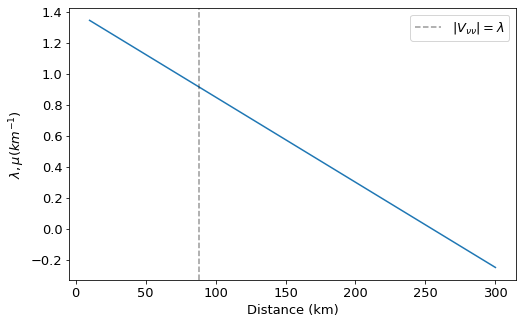

In [ ]:
r = np.linspace(10,300,10**5)
#Mu = pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*r)*0.5
#lambd = 2.5*pow(10,4)*(w/2)*np.exp(-((1.5*w/2)/20)*r)
ratio = 1.4 - 0.0055*r
#@np.vectorize
#def lambd(w):
#  return w*pow(10,3)



#plt.ylim(1e-1,1e5)
plt.plot(r,ratio)
#plt.plot(r,Mu,label=r'$|V_{\nu\nu}|$')
#plt.plot(r,lambd,label=r'$\lambda$')
#plt.axhline(y=w*pow(10,3),color='r',label=r'$\lambda$')
plt.axvline(x=88,color='black',linestyle='--',alpha = 0.4,label = r'$|V_{\nu\nu}|=\lambda$')
plt.xlabel('Distance (km)')
plt.ylabel(r'$\lambda ,\mu  (km^{-1})$')
plt.legend()
#plt.savefig('PotentialsBothDecSASE.pdf')


In [ ]:
class SN_wrap_v2():

  def __init__(self,n1):

    self.n1   = n1           #E bins
    if n1>1:
      self.E  = np.linspace(0,50,n1+1)[:-1]
      self.E += (self.E[1]-self.E[0])*0.5
    else :
      self.E  = np.array([10],dtype=float)

    alpha    = 1
    beta     = 1.5

    self.I = []

    self.I = np.array([[alpha]*3 + [beta]*3])   #Creates an tensor with 3 copies of x's and y's to be multiplied by the P's and Pbar's

    self.I = np.array(self.I).reshape(self.n1,6)

    self.t     = None
    self.out   = None
    self.potential = []

    P0 = []
    for E_bin in self.E:
      P0 += self.P_init(E_bin)     #Makes copies of initial value for the T bins and E bins = P0
    P0 = np.array(P0)
    self.P0 = P0

  #def I_obj(self,t):
  #  self.I = []
  #  alpha = 1
  #  for E_o in self.E:
  #    self.I.append(np.array([[alpha]*3 + [1.4 - 0.0055*(t)]*3]))   #Creates an tensor with 3 copies of x's and y's to be multiplied by the P's and Pbar's

    #self.I = np.array(self.I).reshape(self.n1,6)
    #return self.I

  def init_E_P_theta(self):
    return self.P0.reshape(self.n1,6), self.E

  def __call__(self,t,P):

   return self.SN_self_v3(t,P,self.E,self.I)

  #def Dist(self,t):
  #      R = 10
  #      return 0.75*(R/t)**4 #0.5*(1-np.sqrt(1-(R/t)**2))**2

  def P_init(self,E):                    # Generates initial values of P and Pbar
    P1 =  [0,0,1]   #[0,0,(self.phi(E,0.315)/10 - self.phi(E,0.131)/24)/(self.phi(E,0.315)/10 + self.phi(E,0.131)/24 )]
    P2 =  [0,0,1]

    return P1 + P2                      #Returns a vector with dim 6

  def omega(self,E):                              # Vacuum potential calc func
    dm2 = 2 * 10**-9                              # In terms of eV
    conv = 0.506 * 10**10                         # conversion factor eV -> 1/km
    w = (dm2 * conv)/(2*E)
    return w

  def SN_self_v3(self,t,P,E,I):    # Multiangle system definition

    dE      = 2*E[0]
    E_bin   = self.E
    w       = self.omega(E_bin)

    theta_v = 0.15                        # theta vacuum
    lambd   = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)#250 #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t) #lambda_f(t)#          # Matter potential

    mu_p    = 5*(pow(10,3)*np.exp(-(0.253/15)*t))#2.53*pow(10,3)*np.exp(-(0.38/15)*t)#9*pow(10,3)*(0.275/2)*np.exp(-((0.115)/25)*t)##2.53*pow(10,3)*np.exp(-(0.38/15)*t)#pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)#abs(mu_f(t))#

    #lambd   = 550 #7.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t) #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t) #0.253*pow(10,3)   #pow(10,4)*(0.253/2)*np.exp(-((1.5*0.253/2)/10)*t)            #1.1474e6*pow(t,-2.263)         # Matter potential

    #mu_p    = 1.5*(pow(10,3)*np.exp(-(0.253/15)*t))#pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)  #pow(10,4)*2.53*np.exp(-(1.5*0.253/10)*t) #5.3e5*self.Dist(t) #2.123e6*self.Dist(t)

    P       = P.reshape(self.n1,6)

    #I       = self.I_obj(t)

    int_E   = (I*P).sum(axis=0)

    int_E   = int_E[0:3] - int_E[3:6]          #Does element wise multiplication of xP and yP_b and stores it in the object

    int_D = (int_E)

    P1, P2 = P[:,0:3], P[:,3:6]

    H1 = (np.array(  [  w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w, lambd  - w*np.cos(2*theta_v)]).T.reshape(self.n1,3) + mu_p*int_D)

    H2 = (np.array(  [ -w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w , lambd + w*np.cos(2*theta_v)]).T.reshape(self.n1,3) + mu_p*int_D)

    dP1dt = np.cross(H1, P1)
    dP2dt = np.cross(H2, P2)

    dPdt = np.concatenate((dP1dt,dP2dt),axis=1)

    return dPdt

  def solver(self,t0=20,tf=500):

    t_span=(t0,tf)
    self.potential = []
    sol = RK45(self,t0,self.P0,tf,vectorized=True,rtol = 1e-6, atol = 1e-6)

    t_values  = []
    y_values  = []

    while(True):
      # Get solution step state
      sol.step()
      t_values.append(sol.t)
      y_values.append(sol.y)


      # Break loop after modeling is finished
      if sol.status == 'finished':
        break

    t   = np.array(t_values)
    out = np.array(y_values)

    self.t = t
    self.out = out.reshape(-1,self.n1,6)

    return self.t, self.out

  def show_plot(self,bins=None):
    if bins==None:
      E_bins = np.arange(0,self.n1,1)
    else :
      E_bins = bins
    fig,ax = plt.subplots(1,2,figsize=(30,8))

    for i in E_bins:
      ax[0].plot(t,self.out.reshape(-1,self.n1,6)[:,i,2],label = r'$P_z$({})'.format(E[i]))
      ax[0].legend()
      ax[0].set_xlabel('r(km)')
      ax[0].set_title(r'$P_z$', fontsize=15)

    for i in E_bins:
      ax[1].plot(t,self.out.reshape(-1,self.n1,6)[:,i,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))
      ax[1].legend()
      ax[1].set_xlabel('r(km)')
      ax[1].set_title(r'$\overline{P_z}$', fontsize=15)

  def J_J_bar(self):
     if self.out is not None:
      dE = 2*self.E[0]
      I = self.I
      int_D = (I*self.out).sum(axis=1)

      J     = int_D[:,0:3]#*dE/2
      J_bar = int_D[:,3:6]#*dE/2

      return J,J_bar

In [ ]:
SN_obj = SN_wrap_v2(n1=1)  #(n1=70)

P0, E = SN_obj.init_E_P_theta()

In [ ]:
t, out= SN_obj.solver()

In [ ]:
J, J_bar  = SN_obj.J_J_bar()
int_E_z   = J[:,2] - J_bar[:,2]
#potential = 550  + int_E_z*1.5*(pow(10,3)*np.exp(-(0.253/15)*t))#pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t) #2.5*pow(10,4)*(w/2)*np.exp(-((1.5*w/2)/20)*t)
lambd   = 250 + 0*t#2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)#lambda_f(t)#11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t) #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)         # Matter potential
mu_p    = 2.53*pow(10,3)*np.exp(-(0.38/15)*t)#9*pow(10,3)*(0.275/2)*np.exp(-((0.115)/25)*t)#pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)#abs(mu_f(t))#5*(pow(10,3)*np.exp(-(0.253/15)*t))
potential = lambd + int_E_z*mu_p  #11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t) + int_E_z*5*(pow(10,3)*np.exp(-(0.253/15)*t))

In [ ]:
t.shape

(270834,)

Text(0.5, 1.0, 'intD-SA')

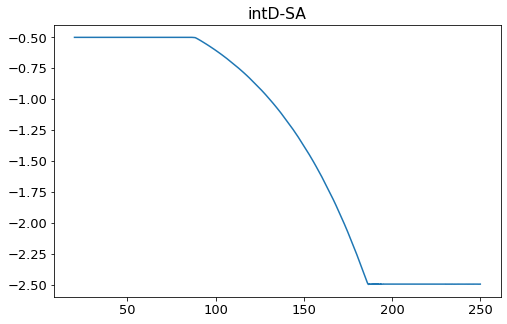

In [ ]:
plt.plot(t,int_E_z)
plt.title('intD-SA')
#plt.savefig('intDz_SA.jpeg')

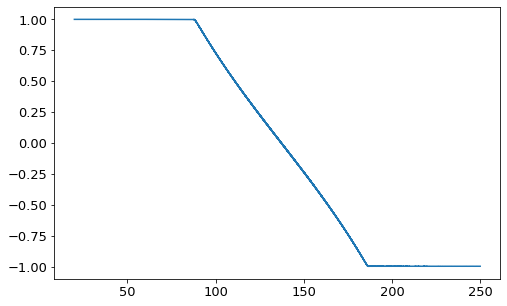

In [ ]:
plt.plot(t, J[:,2])

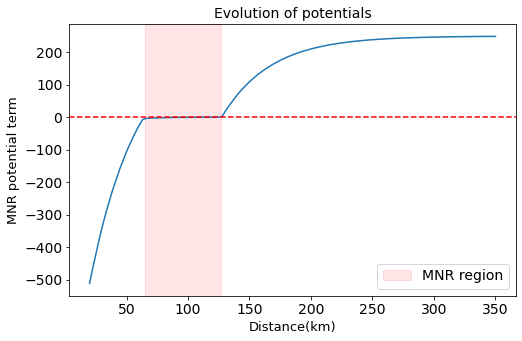

In [ ]:
plt.plot(t,potential)
plt.title('Evolution of potentials',fontsize=14)
plt.xlabel('Distance(km)',fontsize=13)
plt.axhline(y=0,color='r',linestyle ='--')
plt.axvspan(65,127,alpha=0.1,color='red',label='MNR region')
plt.ylabel('MNR potential term',fontsize=13)
plt.legend()
plt.savefig('IntDzEvol_SASE_ConstLa.pdf')

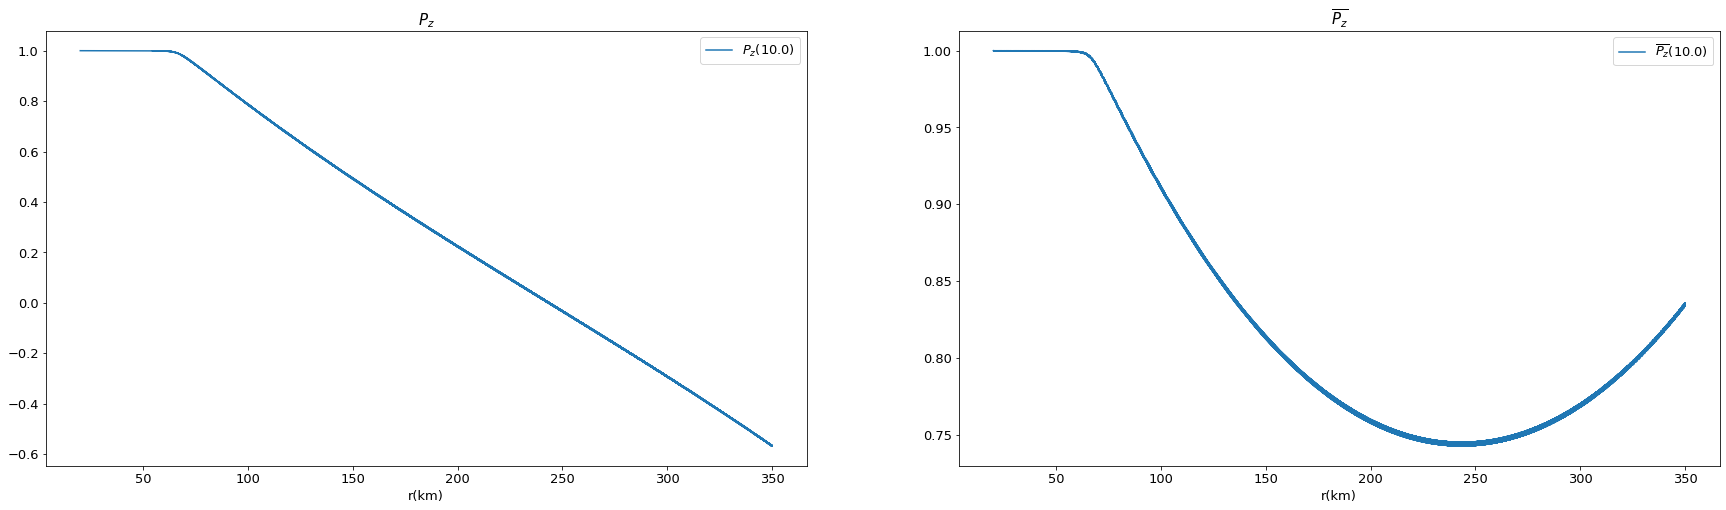

In [ ]:
SN_obj.show_plot() #bins=[2,6,9,11,15] 70bins=[7,17,26,32,43] 50bins=[5,12,19,23,31]
#plt.savefig('SingleAngle70Ebin.jpeg')

In [ ]:
Pf = out[:,:,2]    #Final neutrino value
Pfb = out[:,:,5]   #Final anti-neutrino value
Pf.shape
Pi  = P0[:,2]    #Initial neutrino
Pib = P0[:,5]    #Initial anti-neutrino
P_ee = 0.5*(1+ Pf/Pi)
P_eeb = 0.5*(1+ Pfb/Pib)
P_ee.shape


(136160, 1)

In [ ]:
P = out[:,0,0:3]
P_bar = out[:,0,3:6]

In [ ]:
P_bar.shape

(270834, 3)

In [ ]:
int_D = J - J_bar
int_D.shape

(270834, 3)

In [ ]:
t.shape

(270834,)

In [ ]:
P.shape

(270834, 3)

In [ ]:
P_bar.shape

(270834, 3)

In [ ]:
int_D.shape

(270834, 3)

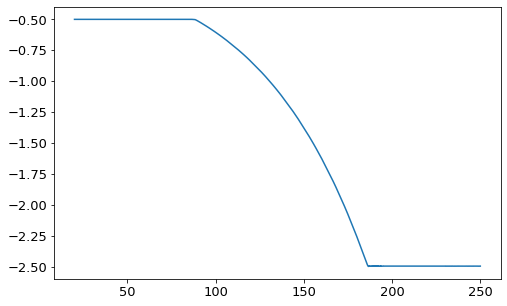

In [ ]:
plt.plot(t, int_D[:,2] )#- SN_obj.omega(10)*np.cos(2*0.15) )

In [ ]:
89 + 102

191

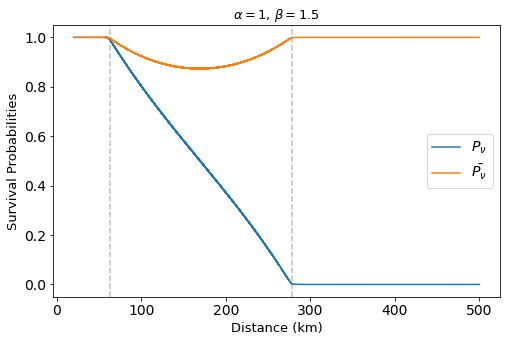

In [ ]:
plt.plot(t,P_ee, label = r'$P_{\nu}$')
plt.plot(t, P_eeb,label = r'$\bar{P_{\nu}}$')
plt.title(r'$\alpha = 1$, $\beta = 1.5$',fontsize=13)
plt.xlabel('Distance (km)',fontsize=13)
plt.ylabel('Survival Probabilities',fontsize=13)
plt.axvline(63,color='grey',linestyle='--',alpha=0.5)
plt.axvline(278,color='grey',linestyle='--',alpha=0.5)
plt.legend()
#plt.savefig('P_surv_BothDec_SASE.pdf')

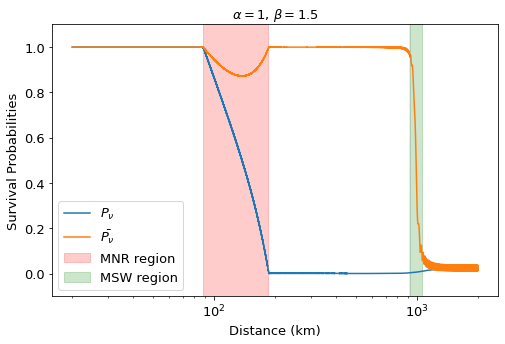

In [ ]:
plt.plot(t,P_ee, label = r'$P_{\nu}$')
plt.plot(t, P_eeb,label = r'$\bar{P_{\nu}}$')
plt.title(r'$\alpha = 1$, $\beta = 1.5$',fontsize=13)
plt.xlabel('Distance (km)',fontsize=13)
plt.ylabel('Survival Probabilities',fontsize=13)
#plt.axvline(x=62,color ='black', alpha = 0.4, linestyle = '--')
#plt.text(84,0.4,'x=87km',rotation=90)
#plt.axvline(x=279,color ='black', alpha = 0.4, linestyle = '--')
plt.ylim(-0.1,1.1)
plt.axvline(920,color='grey',alpha=0.2)
plt.axvspan(88,185,label='MNR region',color='red',alpha=0.2)
plt.axvspan(920,1060,color='green',alpha=0.2,label='MSW region')
plt.xscale('log')
plt.legend()
plt.savefig('P_surv_BothDec_SASE_withMSW.pdf')

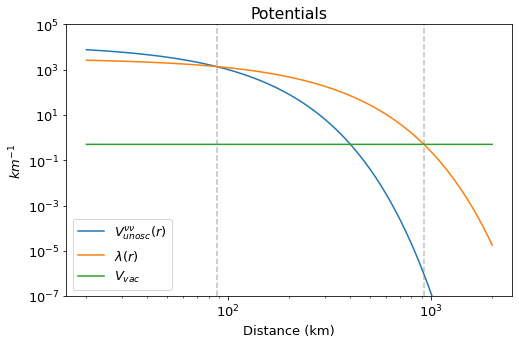

In [ ]:
plt.plot(t,Mu,label=r'$V^{\nu\nu}_{unosc}(r)$')
plt.plot(t,lambd,label=r'$\lambda(r)$')
plt.plot(t, 0.506 + 0*t,label=r'$V_{vac}$')
plt.yscale('log')
plt.xscale('log')
plt.title('Potentials')
plt.xlabel('Distance (km)')
plt.ylabel(r'$km^{-1}$')
plt.legend()
plt.axvline(88,alpha=0.5,color='gray',linestyle='--')
plt.axvline(920,alpha=0.5,color='gray',linestyle='--')
plt.ylim(1e-7,1e5)
plt.savefig('Potentials_SASE_withMSW.pdf')

In [ ]:
SN_obj.omega(10)

0.506

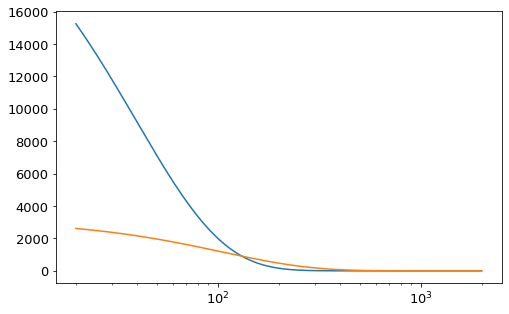

In [ ]:
plt.plot(t,Mu)
plt.plot(t,lambd)
plt.xscale('log')

In [ ]:
mu,lambd,r,tau = smp.symbols('mu, lambda, r, tau')

In [ ]:
r = np.linspace(10,200,10000)

In [ ]:
mu = 5*pow(10,3)*smp.exp(-(0.253/15)*r)#2.53*pow(10,3)*smp.exp(-(0.38/15)*r)#9*pow(10,3)*(0.275/2)*smp.exp(-((0.115)/25)*r)# #pow(10,4)*2.53*smp.exp(-(1.5*0.253/15)*r)
lambd = 1.581*pow(10,3)*smp.exp(-(0.235/25)*r)#250#5*pow(10,3)*(0.275/2)*smp.exp(-((0.115)/25)*r)#2.5*pow(10,4)*(0.253/2)*smp.exp(-((1.5*0.253/2)/20)*r)
mu


5000*exp(-0.0168666666666667*r)

In [ ]:
lambd

1581.0*exp(-0.0094*r)

In [ ]:
tau = 1/smp.Abs(smp.diff(smp.ln(lambd/mu),r))
tau

133.928571428571

In [ ]:
del_t1 = tau*smp.ln((1+1.5)/(1.5-1)).simplify()
del_t1

215.549720415281

In [ ]:
del_t1_f = smp.lambdify(r,del_t1)

In [ ]:
plt.plot(r,del_t1_f(r))

In [ ]:


Mu = pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t) *0.5
lambd = 2.5*pow(10,4)*(0.253/2)*np.exp(-((1.5*0.253/2)/20)*t)
ratio = lambd/Mu


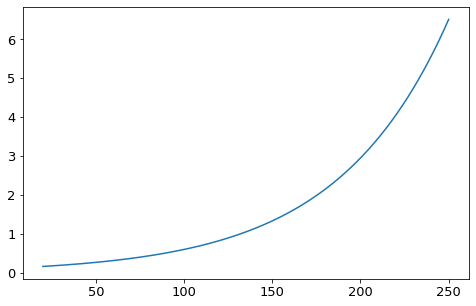

In [ ]:
plt.plot(t,ratio)

In [ ]:
vac = 0.506*np.cos(0.2) + 0*t

In [ ]:
alpha = 1.5

In [ ]:
P_analy = 0.5*(1+(alpha**2-ratio**2-1)/(2*ratio))
Pb_analy = 0.5*(1+(alpha**2+(ratio**2)-1)/(2*1.5*ratio))

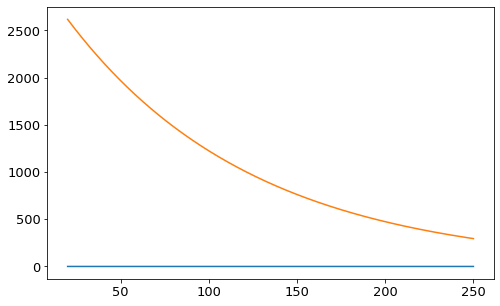

In [ ]:
plt.plot(t,vac)
plt.plot(t,lambd)
#plt.ylim(0,2)
#plt.xlim(900,1100)
#plt.axvline(921)

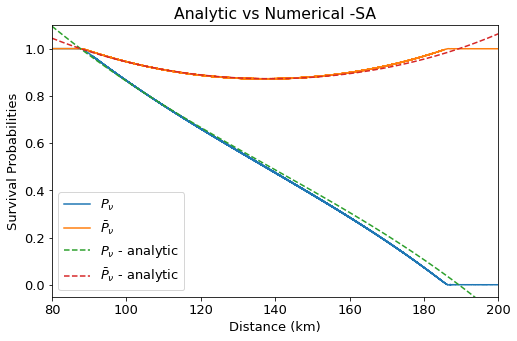

In [ ]:
plt.plot(t,P_ee,label=r'$P_\nu$')
plt.plot(t,P_eeb,label=r'$\bar{P}_{\nu}$')
plt.plot(t,P_analy,linestyle='--',label=r'$P_{\nu}$ - analytic')
plt.plot(t,Pb_analy,linestyle='--',label=r'$\bar{P}_{\nu}$ - analytic')
plt.xlim(80,200)
plt.ylim(-0.05,1.1)
#plt.axhline(0)
#plt.axhline(1)
plt.title('Analytic vs Numerical -SA')
plt.xlabel('Distance (km)')
plt.ylabel('Survival Probabilities')
plt.legend()
#plt.savefig('AnalyticVsNumericalP_surv_SA_longerdist.pdf')

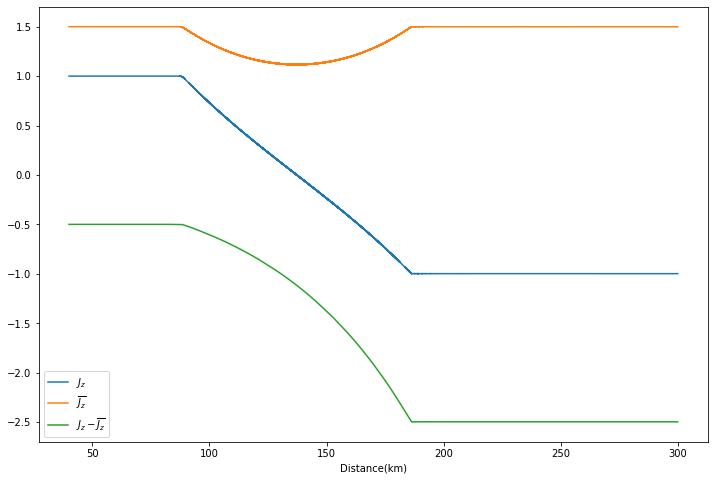

In [ ]:
plt.plot(t,J[:,2])
plt.plot(t,J_bar[:,2])
plt.plot(t,J[:,2] - J_bar[:,2])
plt.xlabel('Distance(km)')
#plt.title('ELN conservation - SingleAngle')
plt.legend([r'$J_z$',r'$\overline{J_z}$',r'$J_z - \overline{J_z}$'])
#plt.savefig('SingleAngleDz.jpeg')

In [ ]:
P1 = int_E_z[0]
P2 = int_E_z[1]
P3 = int_E_z[2]


In [ ]:
int_D = np.array([P1,P2,P3])

In [ ]:
abs(int_D)

array([0.49999999, 0.49999992, 0.4999997 ])

# Multiangle Single Energy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import RK45, solve_ivp
import os
import matplotlib

matplotlib.rcParams['figure.figsize'] = (12,8)
matplotlib.rcParams['font.size']      = 10

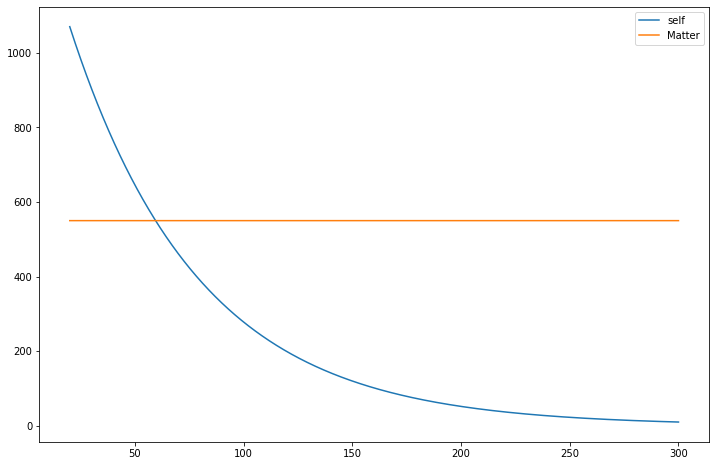

In [ ]:
r = np.linspace(20,300,10**5)
plt.plot(r,1.5*(pow(10,3)*np.exp(-(0.253/15)*r)),label='self')
plt.plot(r,550+ 0*7.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*r),label='Matter')
plt.legend()
#plt.axvline(x=60)

In [ ]:
class SN_wrap_v2():
  def __init__(self,n1,n2):

    self.n1    = n1           #E bins
    self.n2    = n2           #Theta bins
    if n1>1:
      self.E     = np.linspace(0,50,n1+1)[:-1]
      self.E    += (self.E[1]-self.E[0])*0.5
    else :
      self.E = np.array([10]).reshape(-1,1)

    if n2>1:
      self.thetas = np.linspace(0,np.pi,n2+1)[:-1]
      self.thetas += (self.thetas[1]-self.thetas[0])*0.5
      self.thetas = self.thetas.reshape(-1,1)
    else :
      theta_max = np.pi
      theta_min = 0
      self.thetas = np.array([(theta_max - theta_min)/2]).reshape(-1,1)

    self.int_p_theta = 0

    self.I = []
    alpha = 1
    beta = 1.5
    for E_o in self.E:
      self.I.append(np.array([[alpha]*3 + [beta]*3]*self.n2))   #Creates an tensor with 3 copies of x's and y's to be multiplied by the P's and Pbar's

    self.I = np.array(self.I).reshape(self.n1,self.n2,6)

    self.t     = None
    self.out   = None

    P0 = []
    for theta_bin in self.thetas:
      P0 += self.P_init(theta_bin)*self.n1   #Makes copies of initial value for the T bins and E bins = P0
    P0 = np.array(P0)
    self.P0 = P0

    self.theta_temp = self.thetas[:,0]
    self.dcost = (np.cos(self.theta_temp[self.n2-1]) - np.cos(self.theta_temp[0]))/self.n2

  def init_E_P_theta(self):
    return self.P0.reshape(self.n1,self.n2,6), self.E,self.thetas

  def __call__(self,t,P):

   return self.SN_self_v3(t,P,self.E,self.thetas,self.I)

  def P_init(self,theta):                    # Generates initial values of P and Pbar
    P1 =  [0,0,0.5]
    P2 =  [0,0,0.5]

    return P1 + P2                      #Returns a vector with dim 6

  def omega(self,E):                              # Vacuum potential calc func
    dm2 = 2 * 10**-9                              # In terms of eV
    conv = 0.506 * 10**10                         # conversion factor eV -> 1/km
    w = (dm2 * conv)/(2*E)
    return w

  def SN_self_v3(self,t,P,E,thetas,I):   # Multiangle system definition

    dcost   = -self.dcost

    theta_v = 0.16                       # theta vacuum

    lambd   = 7.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t) #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)         # Matter potential

    mu_p    = 1.5*(pow(10,3)*np.exp(-(0.253/15)*t)) #pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)

    P       = P.reshape(self.n1,self.n2,6)

    int_E = (I*P).sum(axis=0)           #Does element wise multiplication of xP and yP_b and stores it in the object

    int_E = int_E[:,0:3] - int_E[:,3:6]   #Separates xP and yP_b and subtracts it

    E_bin = E
    theta_bin = thetas

    U = []

    for theta_bin in thetas:
      U.append((1-np.cos(theta_bin)*np.cos(thetas)))

    U = np.array(U).reshape(self.n2,self.n2,1) #Reshapes it into the correct shape

    int_D = ((U*int_E)*dcost).sum(axis=0)         #Multiplies it with int_E element wise to get A1(x1P11-y1Pb11 + x2P21-y2Pb21 +...) + A2(x1P12-y1Pb12 + ...) +...

    w = self.omega(E_bin)

    P1, P2 = P[:,:,0:3], P[:,:,3:6]

    H1 = (np.array(  [ w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w, lambd + w*np.cos(2*theta_v)]).T.reshape(self.n1,1,3) + mu_p*int_D)

    H2 = (np.array(  [ -w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w , lambd - w*np.cos(2*theta_v)]).T.reshape(self.n1,1,3) + mu_p*int_D)

    dP1dt = np.cross(H1, P1)
    dP2dt = np.cross(H2, P2)

    dPdt = np.concatenate((dP1dt,dP2dt),axis=2)

    return dPdt

  def solver(self,t0=40,tf=200):

    t_span=(t0,tf)
    sol = RK45(self,t0,self.P0,tf,vectorized=True,rtol=1e-6,atol=1e-6)

    t_values = []
    y_values = []

    while(True):
      # Get solution step state
      sol.step()
      t_values.append(sol.t)
      y_values.append(sol.y)

      # Break loop after modeling is finished
      if sol.status == 'finished':
        break

    t   = np.array(t_values)
    out = np.array(y_values)

    self.t = t
    self.out = out.reshape(-1,self.n1,self.n2,6)

    #costheta = np.cos(self.thetas).reshape(1,1,-1,1)
    self.int_p_theta = (self.out.reshape(-1,self.n1,self.n2,6)).sum(axis=2)/self.n2

    self.int_p_theta

    return self.t, self.out

  def show_plot(self,bins=None):
    if bins==None:
      E_bins = np.arange(0,self.n2,1)
    else :
      E_bins = bins
    for j in range(self.n2):
      for i in E_bins:
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,2],label = r'$P_z$({})'.format(E[i]))
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))
      plt.title(f'Theta : {theta[j][0]}')
      plt.xlabel('r (km)')
      plt.legend()
      plt.show()
      plt.close()

  def J_J_bar(self):
     if self.out is not None:
      dE = 2*self.E[0]
      I = self.I[:,0,:]
      int_D = (I*self.int_p_theta).sum(axis=1)

      J     = int_D[:,0:3]*dE/2
      J_bar = int_D[:,3:6]*dE/2

      #Diff = (J-J_bar)*(2*np.pi/(self.A + self.B)*dE).sum(axis=0)

      return J,J_bar

In [ ]:
SN_obj = SN_wrap_v2(n1=1,n2=25)

P0, E, theta = SN_obj.init_E_P_theta()

In [ ]:
#Normalization check
P_initial=SN_obj.P0.reshape(SN_obj.n1,SN_obj.n2,6)
dcost = -SN_obj.dcost

(P_initial*dcost).sum(axis=1)


array([[0.        , 0.        , 0.99802673, 0.        , 0.        ,
        0.99802673]])

In [ ]:
P_initial

array([[[0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5],
        [0. , 0. , 0.5, 0. , 0. , 0.5]]]

In [ ]:
t, out = SN_obj.solver()

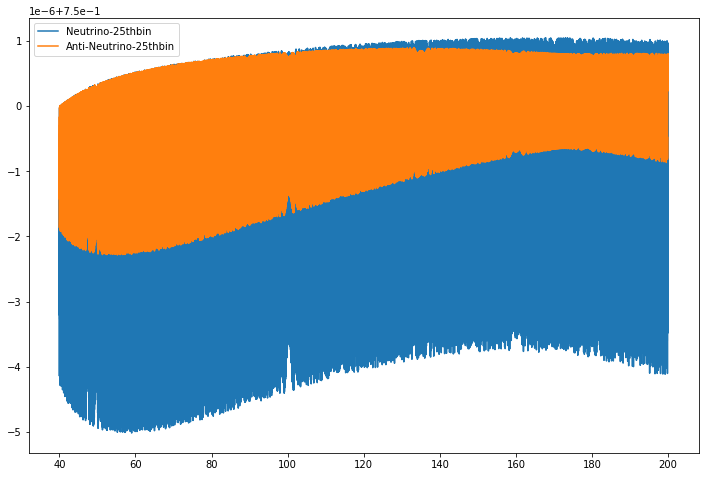

In [ ]:
plt.plot(t,0.5*(1+out[:,:,24,2]),label='Neutrino-25thbin')
plt.plot(t,0.5*(1+out[:,:,24,5]),label='Anti-Neutrino-25thbin')
#plt.axvline(x=130,color='violet',alpha=0.5,label='1st bin',linestyle='--')
#plt.axvline(x=125,color='indigo',alpha=0.5,label='5th bin',linestyle='--')
#plt.axvline(x=108,color='blue',alpha=0.5,label='10th bin',linestyle='--')
#plt.axvline(x=71,color='green',alpha=0.5,label='15th bin',linestyle='--')
#plt.axvline(x=232,color='r',alpha=0.5,label='20th bin',linestyle='--')
#plt.ylim(0,1)
plt.legend()
#plt.savefig('25thbin.jpeg')

In [ ]:
out.shape

(57489, 1, 25, 6)

In [ ]:
int_p_theta = (out.reshape(-1,SN_obj.n1,SN_obj.n2,6)).sum(axis=2)/(SN_obj.n2)

In [ ]:
int_p_theta.shape

(57489, 1, 6)

In [ ]:
P0i = SN_obj.P0.reshape(SN_obj.n1,SN_obj.n2,6)

In [ ]:
P0i.shape

(1, 25, 6)

In [ ]:
def plot_intP(bins=None):

    if bins==None:
      E_bins = np.arange(0,SN_obj.n2,1)
    else :
      E_bins = bins

    fig,ax = plt.subplots(1,2,figsize=(30,8))

    for i in E_bins:
        ax[0].plot(t,int_p_theta[:,i,2],label = r'$P_z$({})'.format(E[i]))
        ax[0].set_title(r'$<P_{\theta}>$', fontsize=15)
        ax[0].set_xlabel('r (km)')
        ax[0].legend()
    for i in E_bins:
        ax[1].plot(t,int_p_theta[:,i,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))
        ax[1].set_title(r'$<\overline{P_\theta}>$', fontsize=15)
        ax[1].set_xlabel('r (km)')
        ax[1].legend()

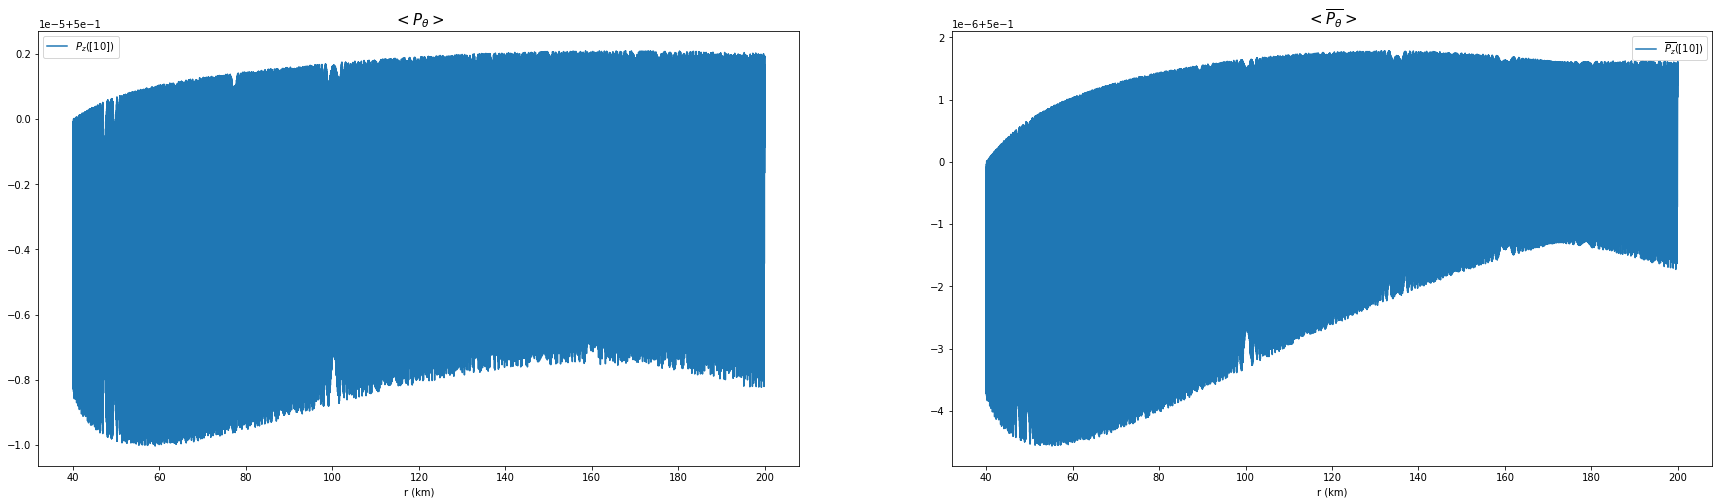

In [ ]:
plot_intP(bins=[0])

In [ ]:
Pf = int_p_theta[:,:,2]
Pfb = int_p_theta[:,:,5]
Pi = P0i[:,0,2]
Pib = P0i[:,0,5]

In [ ]:
P_ee = 0.5*(1+ Pf/Pi)
P_eeb = 0.5*(1 + Pfb/Pib)

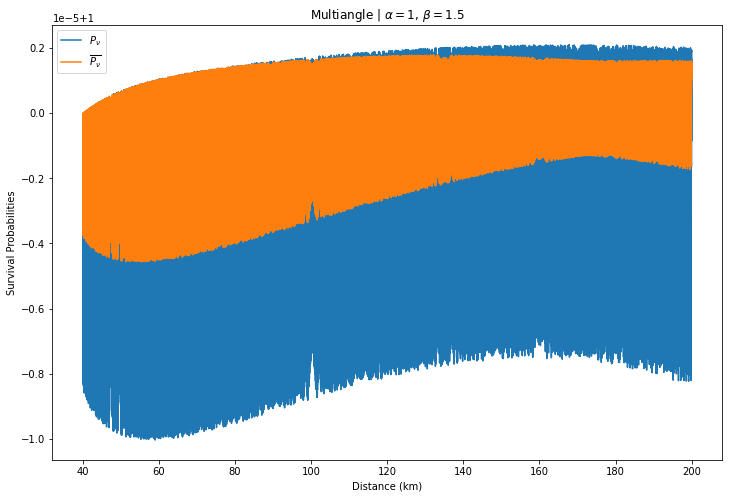

In [ ]:
plt.plot(t,P_ee, label = r'$P_{\nu}$')
plt.plot(t, P_eeb,label = r'$\overline{P_{\nu}}$')
plt.title(r'Multiangle | $\alpha = 1$, $\beta = 1.5$')
plt.xlabel('Distance (km)')
plt.ylabel('Survival Probabilities')
#plt.axvline(x=88,alpha=0.4,color='grey')
#plt.axvline(x=187,alpha=0.4,color='grey')
#plt.text(85,0,'x=88',color='grey',alpha=0.7,rotation=90)
#plt.text(188,0,'x=187',color='grey',alpha=0.7,rotation=270)
#plt.ylim(0,1)
plt.legend()
#plt.savefig('MA_AngleDependentP_P_surv_1_1.5_nub_lesspeaked.pdf')

In [ ]:
def J_J_bar():
     if out is not None:

      I = SN_obj.I
      out_bin = out[:,0,:,:]
      int_D = SN_obj.I*out_bin

      J     = int_D[:,:,0:3]
      J_bar = int_D[:,:,3:6]

      return J,J_bar

      #Previously used method using int_p_theta
      #I = SN_obj.I[:,0,:]
      #int_D = (I*int_p_theta).sum(axis=1)
      #J     = int_D[:,0:3]
      #J_bar = int_D[:,3:6]



In [ ]:
J, J_bar = J_J_bar()
J.shape
int_E_z_1 = J[:,0,2] - J_bar[:,0,2]
potential_1 = 253  + int_E_z_1*pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)


#int_E_z_5 = J[:,4,2] - J_bar[:,4,2]
#int_E_z_10 = J[:,9,2] - J_bar[:,9,2]
#int_E_z_15 = J[:,14,2] - J_bar[:,14,2]
#int_E_z_20 = J[:,19,2] - J_bar[:,19,2]
#int_E_z_25 = J[:,24,2] - J_bar[:,24,2]

#int_E_z = J[:,2] - J_bar[:,2]





potential_1 = 253  + int_E_z_1*pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)      #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)
#potential_5 = 2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)  + int_E_z_5*pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)
#potential_10 = 2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t) + int_E_z_10*pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)
#potential_15 = 2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t) + int_E_z_15*pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)
#potential_20 = 2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t) + int_E_z_20*pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)
#potential_25 = 2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t) + int_E_z_25*pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)


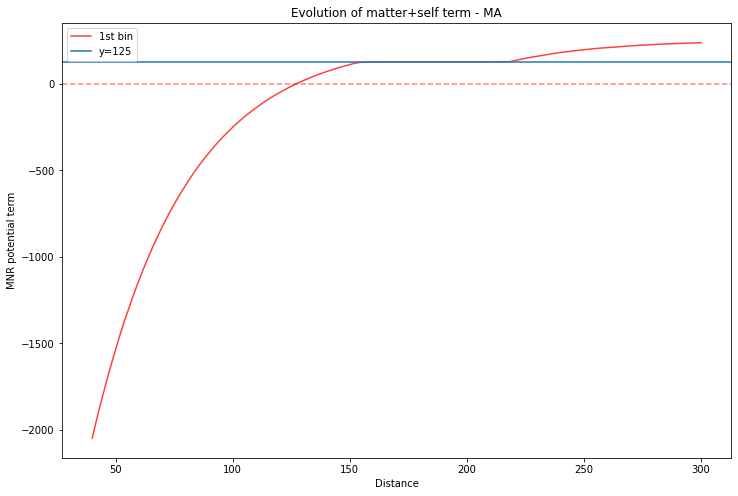

In [ ]:
plt.plot(t,potential_1,color = 'red',alpha=0.75, label='1st bin')
#plt.plot(t,potential_5,color = 'indigo',alpha=0.75, label='5th bin')
#plt.plot(t,potential_10,color = 'blue',alpha=0.75, label='10th bin')
#plt.plot(t,potential_15,color = 'grey',alpha=0.75, label='15th bin')
#plt.plot(t,potential_20,color = 'orange',alpha=1, label='20th bin')
#plt.plot(t,potential_25,color = 'black',alpha=0.75, label='25th bin')
plt.title('Evolution of matter+self term - MA')
plt.xlabel('Distance')
plt.axhline(y=0,alpha = 0.5,color='r',linestyle ='--')
#plt.axvline(x=88,alpha=0.5,color='black',linestyle='--',label = r'$\lambda = \mu$')
#plt.axvspan(88,187,alpha=0.1,color='red',label='MNR region')
plt.ylabel('MNR potential term')
plt.axhline(y=125,label='y=125')
plt.legend()
#plt.savefig('MA-AngleDependentP_Dz_evol_Nub_lesspeaked.pdf')

Text(0.5, 1.0, 'intDz(r)-MA')

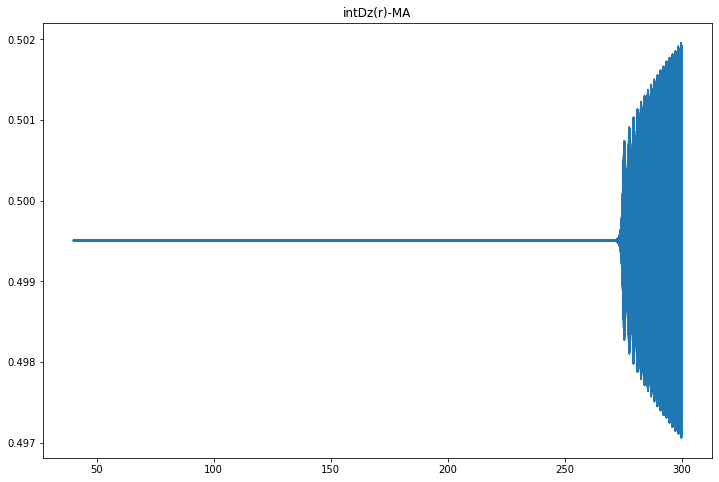

In [ ]:
plt.plot(t,int_E_z_1)
plt.title('intDz(r)-MA')
#plt.savefig('intDz_MA.jpeg')

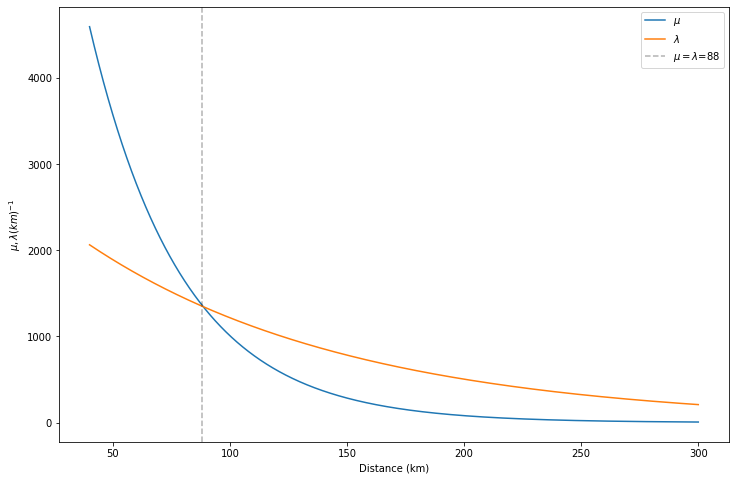

In [ ]:
r = np.linspace(40,300,10**5)
Mu = pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*r)*0.5
lambd = 2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*r)

plt.plot(r,Mu,label = r'$\mu$')
plt.plot(r,lambd,label=r'$\lambda$')
#plt.ylim(-100,4000)
#plt.axhline(y=0.253*pow(10,3),color='r',alpha=0.4,linestyle='-',label = r'$\lambda$')
plt.axvline(x=88,color='black',alpha=0.3,linestyle='--',label=r'$\mu = \lambda$=88')
plt.ylabel(r'$\mu,\lambda (km)^{-1}$')
plt.xlabel('Distance (km)')
plt.legend()
#plt.savefig('PotentialsMA_BothDec_less100.jpeg')
